In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from mlxtend.plotting import plot_decision_regions

import struct

sns.set_theme()

In [4]:
df = sns.load_dataset('titanic').drop(columns=["deck", "class", "embark_town", "alive"])
df['sex'] = df['sex'].replace({'male': 0, "female": 1})

df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna(how = "any")

# now one hot encode a few cols
df['embarked_S'] = (df['embarked'] == "S").astype(np.int64)
df['embarked_C'] = (df['embarked'] == "C").astype(np.int64)
df['embarked_Q'] = (df['embarked'] == "Q").astype(np.int64)
df['is_man'] = (df['who'] == 'man').astype(np.int64)
df['is_woman'] = (df['who'] == 'woman').astype(np.int64)
df['is_child'] = (df['who'] == 'child').astype(np.int64)
df['adult_male'] = df['adult_male'].astype(np.int64)
df['alone'] = df['alone'].astype(np.int64)

df = df.drop(columns=['embarked', 'who'])
df

/tmp/ipykernel_50522/2875798953.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 0, "female": 1})


,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_S,embarked_C,embarked_Q,is_man,is_woman,is_child
0,0,3,0,22.0,1,0,7.2500,1,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,0,0,0,1,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,0,0,1,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,1,1,1,0,0,1,0,0
887,1,1,1,19.0,0,0,30.0000,0,1,1,0,0,0,1,0
888,0,3,1,28.0,1,2,23.4500,0,0,1,0,0,0,1,0
889,1,1,0,26.0,0,0,30.0000,1,1,0,1,0,1,0,0


In [ ]:
A = df.drop(columns=["survived"]).to_numpy()
y = df[["survived"]].to_numpy()
U, S, V = np.linalg.svd(A)
k = 2
A_new = A @ V[:, :k]
A_new
# y_new = pd.DataFrame(y @ V[:, :k])

[1.85113055e+03 7.75634237e+02 4.82731043e+01 3.32985889e+01
 2.55519780e+01 1.97708890e+01 1.63153124e+01 1.00088329e+01
 9.49809479e+00 8.47433755e+00 5.32464352e+00 2.96328900e+00
 9.61169690e-15 1.45263651e-15]


array([[17.59386321,  2.72283094],
       [34.79499831, 15.65198136],
       [21.23813404,  3.51491934],
       ...,
       [23.79422654,  7.55185672],
       [23.07159439,  6.67694374],
       [26.2253535 ,  3.97197624]], shape=(889, 2))

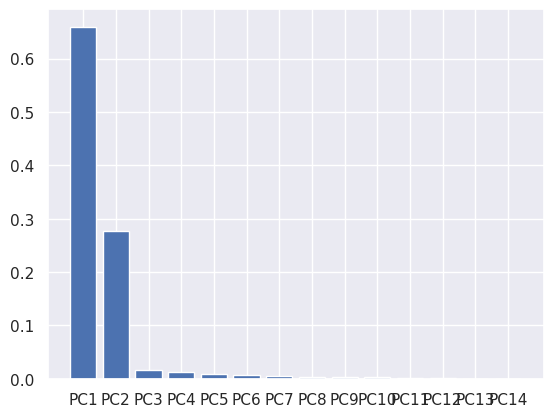

In [12]:
SVD_sum = sum(S)
labels = [f"PC{i}" for i in range(1, len(S)+1)]
relative_variances = S / SVD_sum
plt.bar(labels, relative_variances)
plt.show()

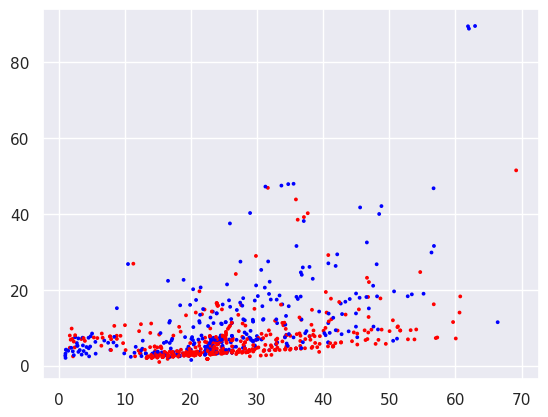

In [11]:
colors = ["Red" if y_i == 0 else "Blue" for y_i in y]
plt.scatter(A_new[:, 0], A_new[:, 1], s=3, c=colors)